# 🌳 Bagging vs 🌲 Random Forest

**Bagging → tree-level sampling (data only)**  
**Random Forest → tree-level (data) + node-level (feature sampling)**  

## 🔹 Bagging (Bootstrap Aggregating)

**Definition:**
An ensemble technique that trains multiple models on different bootstrap samples of the dataset and combines their predictions.

**Key Points:**
- Uses **bootstrap sampling (with replacement)**
- Each model is trained on a **different subset of data**
- Typically uses **decision trees**
- All features are considered at every split
- Reduces **variance** and helps prevent overfitting

**Workflow:**
1. Create multiple bootstrap datasets
2. Train a model on each dataset
3. Aggregate predictions (voting/averaging)

---

## 🔹 Random Forest

**Definition:**
An extension of bagging that adds randomness in feature selection at each split of decision trees.

**Key Points:**
- Uses **bootstrap sampling (same as bagging)**
- Adds **feature sampling at each node**
- Each split considers only a **random subset of features**
- Reduces **correlation between trees**
- Provides better generalization than bagging

**Workflow:**
1. Create bootstrap datasets
2. Train decision trees:
   - At each split, use a random subset of features
3. Aggregate predictions (voting/averaging)

---

## ⚖️ Key Differences

| Feature | Bagging | Random Forest |
|--------|--------|--------------|
| Data Sampling | Yes (bootstrap) | Yes (bootstrap) |
| Feature Sampling | No | Yes (at each node) |
| Tree Correlation | Higher | Lower |
| Overfitting | Reduced | Further reduced |
| Performance | Good | Usually better |

---

## 🧠 One-Line Difference

> Bagging reduces variance using data sampling, while Random Forest reduces variance further using both data and feature sampling.



---

In [2]:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [5]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()


(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.594424,1.351135,-0.439342,-2.005377,-0.733224,0
1,-0.963709,1.331069,-0.652337,-0.675192,-1.702846,0
2,0.704911,-0.269216,-0.281801,-0.139285,-0.653651,1
3,1.628757,0.448582,1.354433,-1.057917,0.025864,1
4,0.923543,-1.150453,2.351219,-3.444430,-1.337957,1


In [6]:
bag = BaggingClassifier(max_features=2)

In [7]:
bag.fit(df.iloc[:,:5],df.iloc[:,-1])

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,2
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


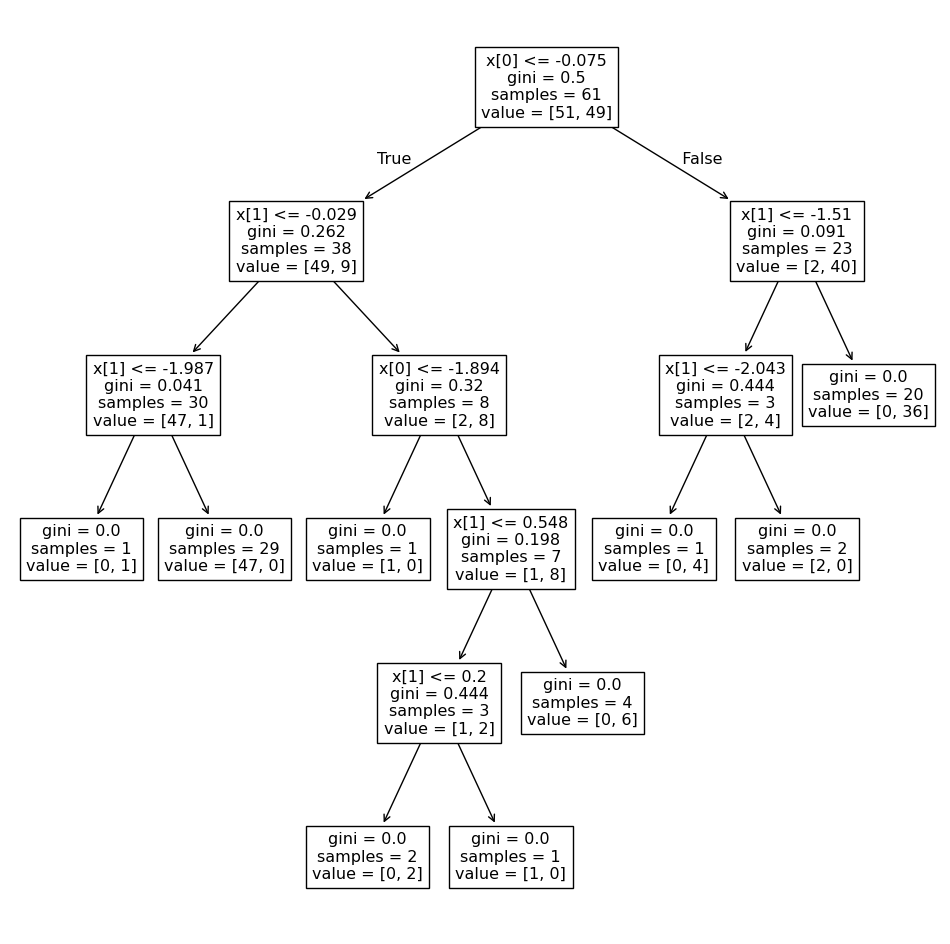

In [8]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [9]:
rf = RandomForestClassifier(max_features=2)

In [10]:
rf.fit(df.iloc[:,:5],df.iloc[:,-1])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


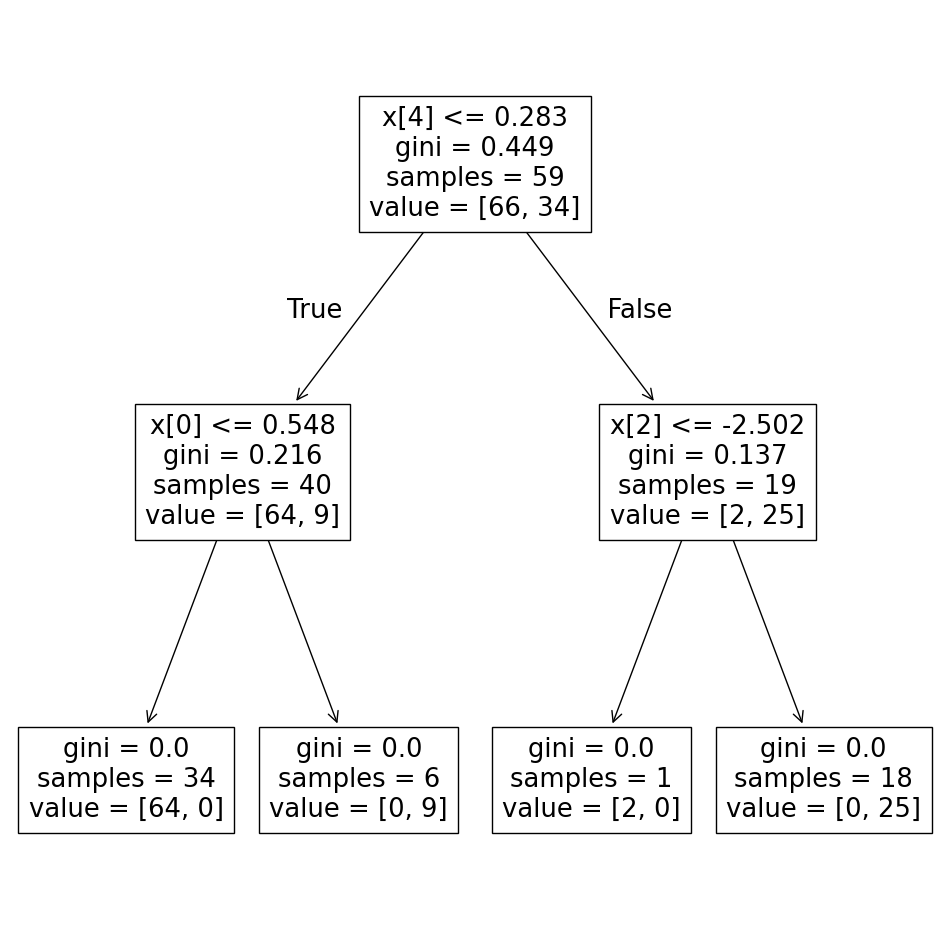

In [11]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()